## Setup

In [13]:
# notebooks/03_exploratory_visualizations.ipynb

import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy import stats
from src.data_loader import DataLoader


## Load Data & Configuration

In [14]:
PROJECT_ROOT = Path.cwd().parent
figures_dir = PROJECT_ROOT / 'reports' / 'figures'
figures_dir.mkdir(parents=True, exist_ok=True)

# Load data
loader = DataLoader()
df = pd.read_csv(loader.processed_dir / "cleaned_data.csv")

# steamId is an identifier, not a real variable — exclude from every plot below.
ID_COLUMNS = ['steamId']
# publisherClass (Indie/AA/AAA/Hobbyist) is the only genuinely low-cardinality
# grouping variable in this dataset. 'name', 'publishers', and 'developers'
# are high-cardinality text (hundreds/thousands of unique values) and would
# make boxplots/scatter colors unreadable if auto-selected.
CATEGORY_COL = 'publisherClass'


def numeric_columns(df: pd.DataFrame) -> list:
    cols = df.select_dtypes(include=['int64', 'float64']).columns
    return list(cols.difference(ID_COLUMNS))


# Set style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")


## 1. Distribution Plots

In [15]:
def create_distribution_plots(df: pd.DataFrame):
    """Create histogram + KDE plots for numeric columns (excluding IDs)."""
    numeric_cols = numeric_columns(df)

    n_cols = 3
    n_rows = (len(numeric_cols) + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
    axes = axes.flatten()

    for idx, col in enumerate(numeric_cols):
        data = df[col].dropna()
        sns.histplot(data, kde=True, ax=axes[idx])
        axes[idx].set_title(f'Distribution of {col}')
        axes[idx].set_xlabel(col)
        axes[idx].set_ylabel('Frequency')
        axes[idx].axvline(data.mean(), color='red', linestyle='--',
                           label=f'Mean: {data.mean():.2f}')
        axes[idx].axvline(data.median(), color='green', linestyle='--',
                           label=f'Median: {data.median():.2f}')
        axes[idx].legend()

    for idx in range(len(numeric_cols), len(axes)):
        fig.delaxes(axes[idx])

    plt.tight_layout()
    plt.savefig(figures_dir / 'distribution_plots.png', dpi=300, bbox_inches='tight')
    plt.show()


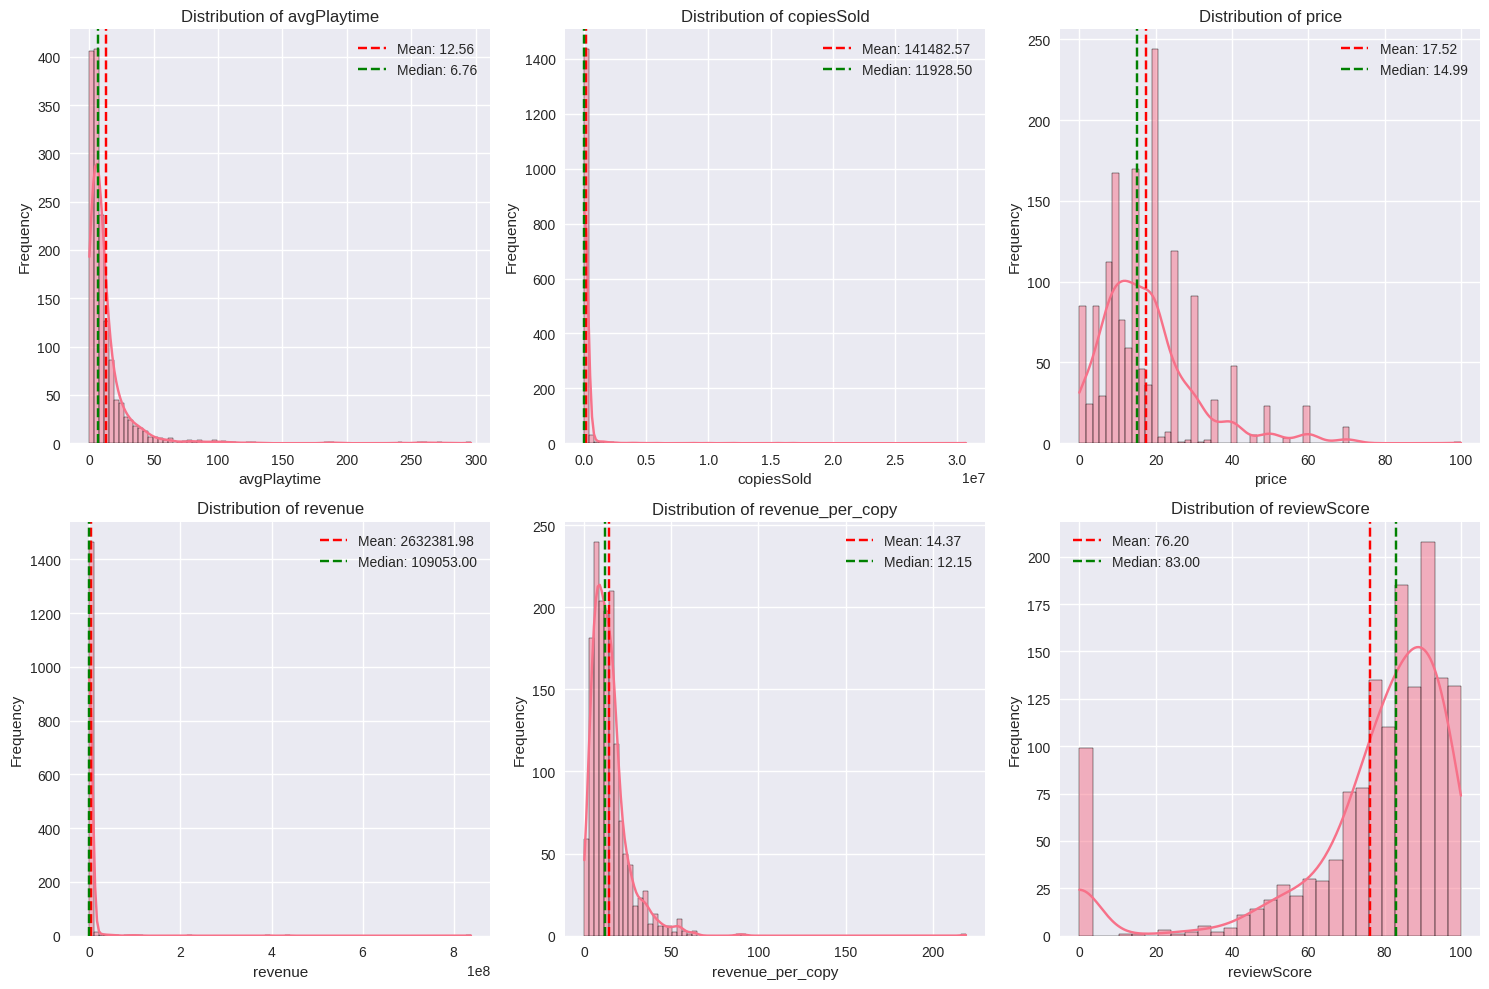

In [16]:
create_distribution_plots(df)


## 2. Box Plots by `publisherClass`

In [17]:
def create_boxplots(df: pd.DataFrame):
    """Create boxplots of each numeric column grouped by publisherClass."""
    numeric_cols = numeric_columns(df)

    if CATEGORY_COL not in df.columns:
        # Fallback: no meaningful grouping variable available
        fig, axes = plt.subplots(1, min(4, len(numeric_cols)), figsize=(15, 5))
        if len(numeric_cols) == 1:
            axes = [axes]
        for idx, col in enumerate(numeric_cols[:4]):
            sns.violinplot(data=df[col].dropna(), ax=axes[idx])
            axes[idx].set_title(f'Distribution of {col}')
            axes[idx].set_ylabel(col)
        plt.tight_layout()
        plt.savefig(figures_dir / 'violin_plots.png', dpi=300, bbox_inches='tight')
        plt.show()
        return

    n_cols = 3
    n_rows = (len(numeric_cols) + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
    axes = axes.flatten()

    for idx, col in enumerate(numeric_cols):
        sns.boxplot(data=df, x=CATEGORY_COL, y=col, ax=axes[idx])
        axes[idx].set_title(f'{col} by {CATEGORY_COL}')
        axes[idx].set_xlabel(CATEGORY_COL)
        axes[idx].set_ylabel(col)
        axes[idx].tick_params(axis='x', rotation=45)

    for idx in range(len(numeric_cols), len(axes)):
        fig.delaxes(axes[idx])

    plt.tight_layout()
    plt.savefig(figures_dir / 'boxplots.png', dpi=300, bbox_inches='tight')
    plt.show()


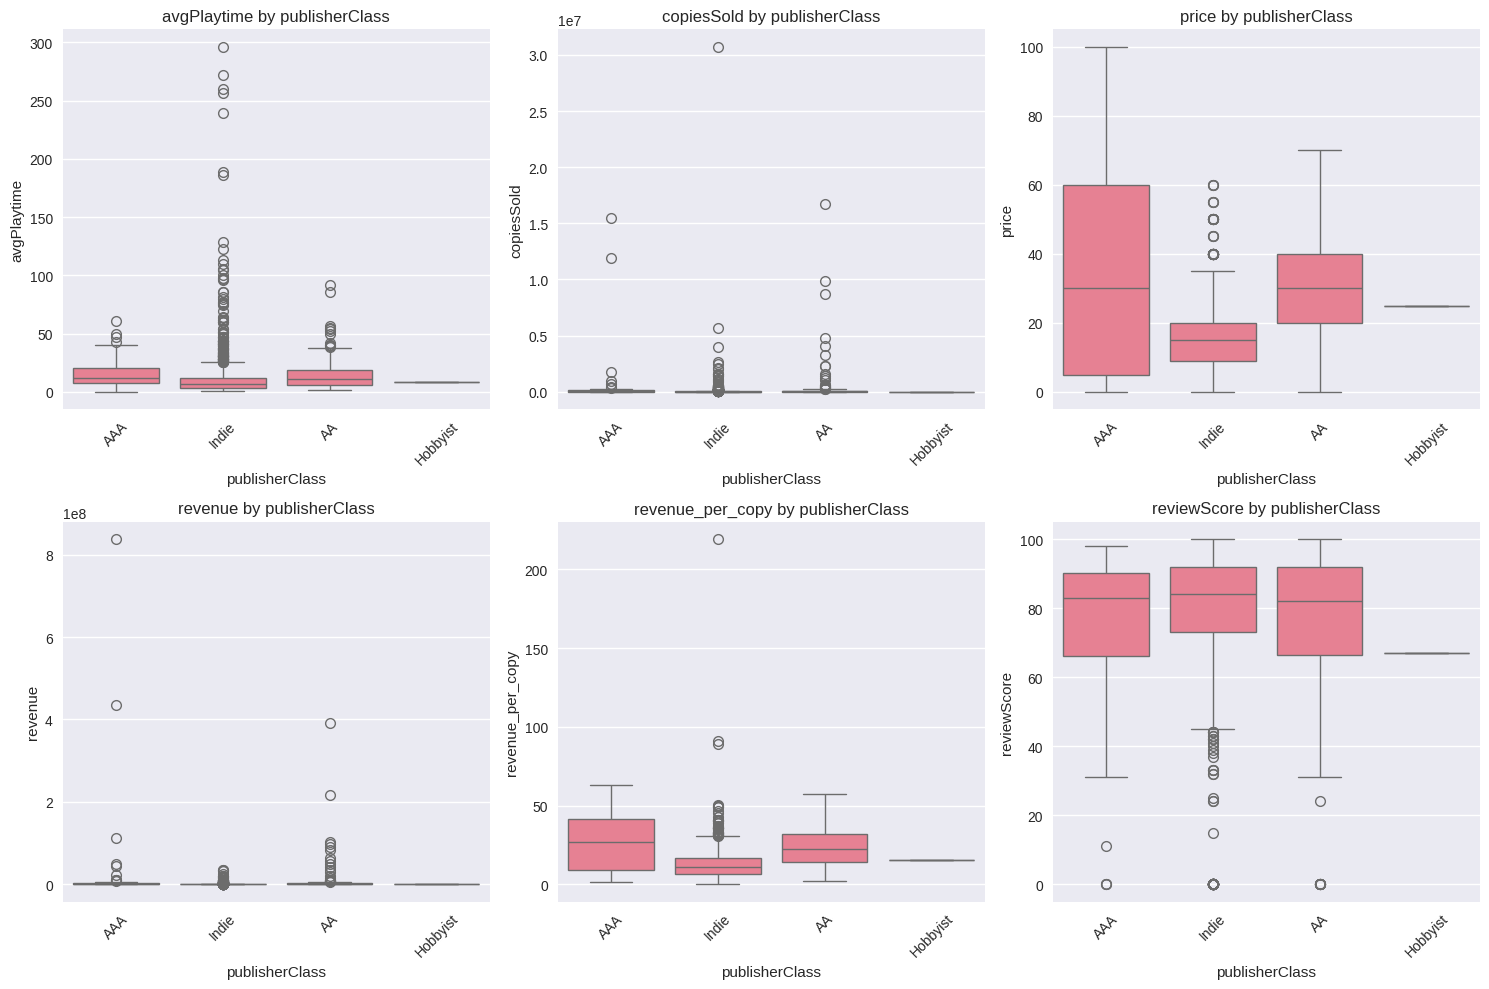

In [18]:
create_boxplots(df)


## 3. Correlation Heatmap

In [19]:
def create_correlation_heatmap(df: pd.DataFrame):
    """Create correlation heatmap (excluding ID columns)."""
    numeric_cols = numeric_columns(df)
    corr = df[numeric_cols].corr()

    fig, ax = plt.subplots(figsize=(10, 8))
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
                cmap='RdBu_r', center=0, square=True, linewidths=0.5, ax=ax)
    ax.set_title('Correlation Heatmap')
    plt.tight_layout()
    plt.savefig(figures_dir / 'correlation_heatmap.png', dpi=300, bbox_inches='tight')
    plt.show()


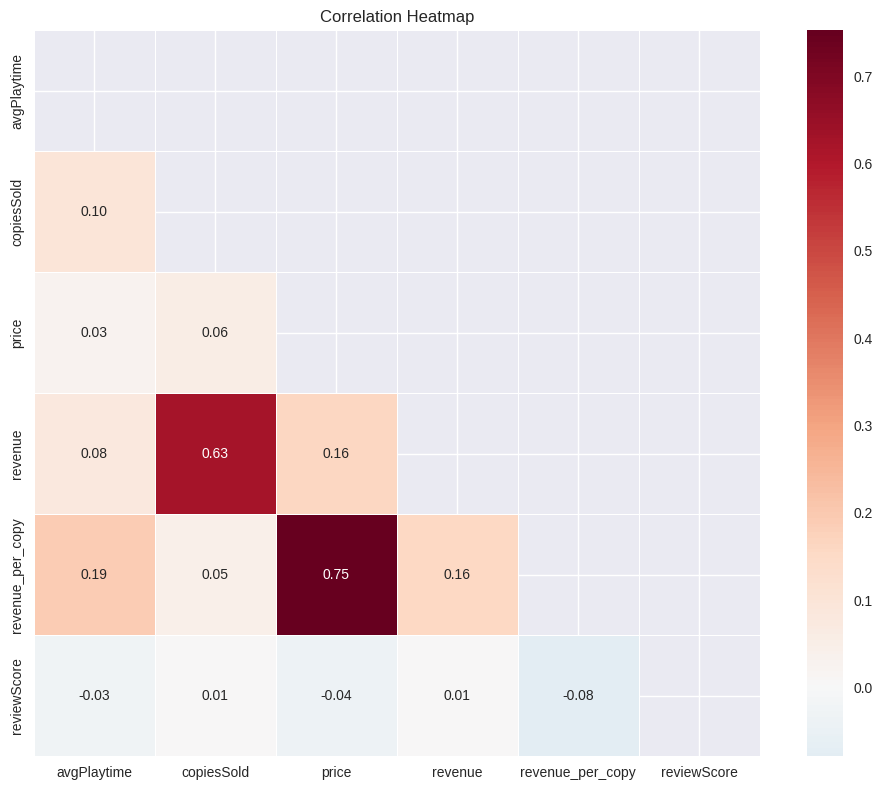

In [20]:
create_correlation_heatmap(df)


## 4. Interactive Plots (Plotly)

In [21]:
def create_interactive_plots(df: pd.DataFrame):
    """Create interactive visualizations with Plotly."""
    numeric_cols = numeric_columns(df)
    color_col = CATEGORY_COL if CATEGORY_COL in df.columns else None

    if len(numeric_cols) <= 5:
        fig = px.scatter_matrix(
            df, dimensions=numeric_cols, color=color_col, title="Scatter Matrix"
        )
        fig.write_html(str(figures_dir / 'scatter_matrix.html'))

    if len(numeric_cols) >= 3:
        x_col, y_col, z_col = numeric_cols[:3]
        fig = px.scatter_3d(
            df, x=x_col, y=y_col, z=z_col, color=color_col,
            title=f"3D Scatter: {x_col} vs {y_col} vs {z_col}",
            opacity=0.7, width=800, height=600
        )
        fig.update_layout(scene=dict(xaxis_title=x_col, yaxis_title=y_col, zaxis_title=z_col))
        fig.write_html(str(figures_dir / '3d_scatter.html'))

    if 1 < len(numeric_cols) <= 4:
        fig = px.scatter_matrix(
            df, dimensions=numeric_cols[:4], color=color_col, title="Interactive Pair Plot"
        )
        fig.write_html(str(figures_dir / 'pair_plot.html'))


In [22]:
create_interactive_plots(df)


## 5. Q-Q Plots for Normality Check

In [23]:
def create_qq_plots(df: pd.DataFrame):
    """Create Q-Q plots for numeric columns (excluding IDs)."""
    numeric_cols = numeric_columns(df)

    n_cols = 3
    n_rows = (len(numeric_cols) + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
    axes = axes.flatten()

    for idx, col in enumerate(numeric_cols):
        data = df[col].dropna()
        stats.probplot(data, dist="norm", plot=axes[idx])
        axes[idx].set_title(f'Q-Q Plot: {col}')
        if len(data) > 3:
            _, p_value = stats.shapiro(data)
            axes[idx].text(0.05, 0.95, f'p = {p_value:.3g}',
                            transform=axes[idx].transAxes, verticalalignment='top',
                            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    for idx in range(len(numeric_cols), len(axes)):
        fig.delaxes(axes[idx])

    plt.tight_layout()
    plt.savefig(figures_dir / 'qq_plots.png', dpi=300, bbox_inches='tight')
    plt.show()


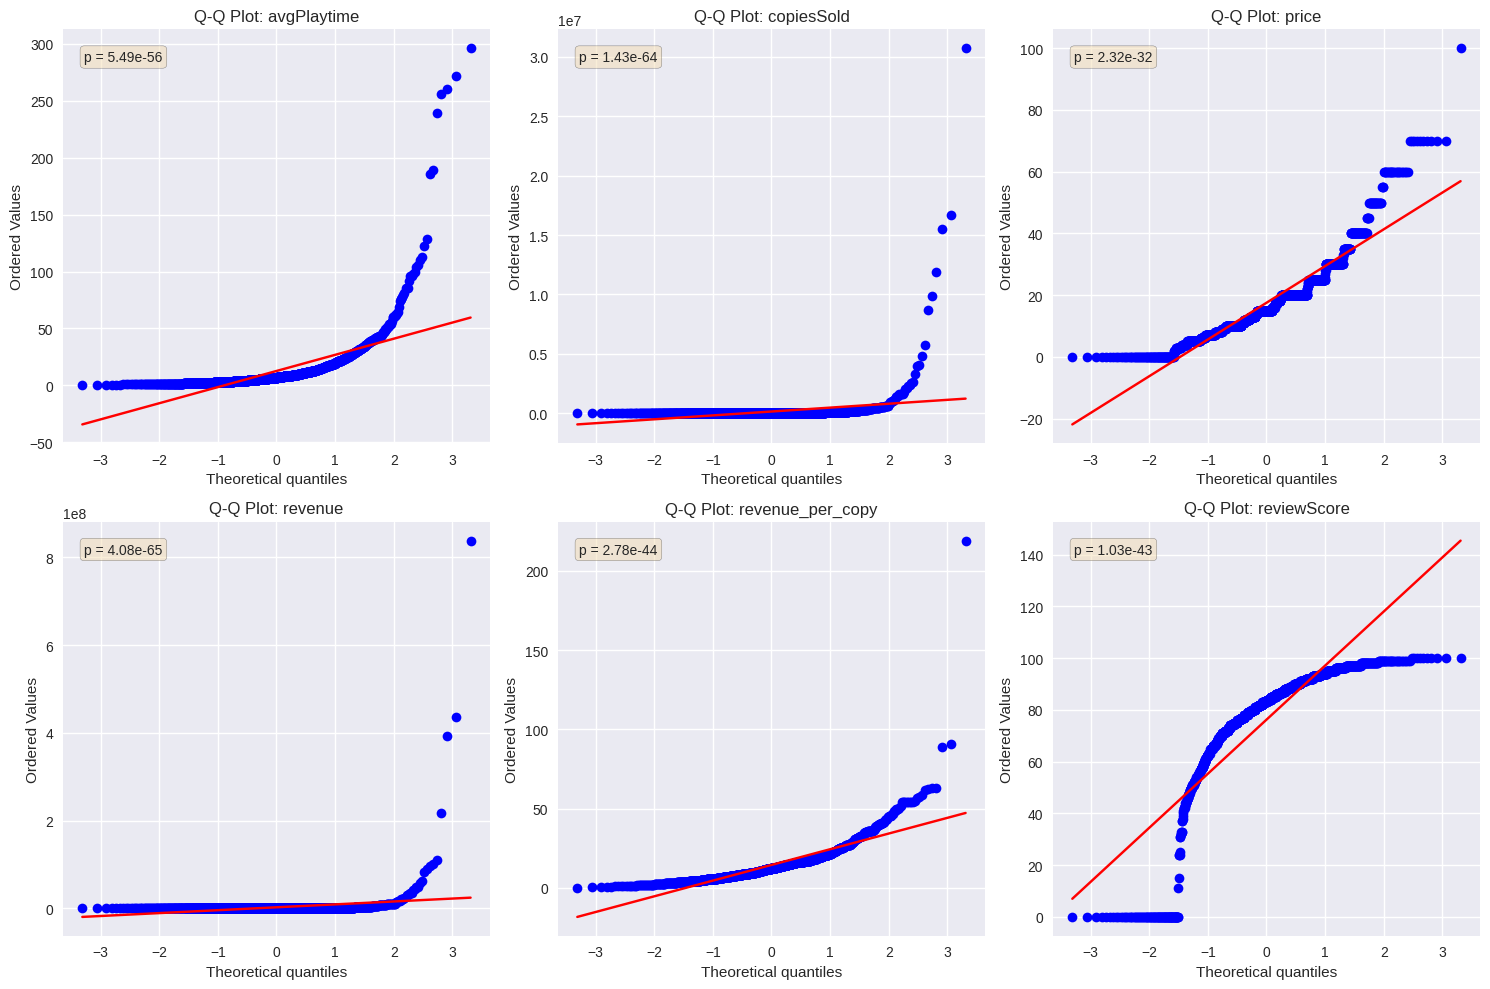

All visualizations created successfully!


In [24]:
create_qq_plots(df)

print("All visualizations created successfully!")
